# Capítulo 3 — Do Átomo ao Nanocristal: Construindo um Ponto Quântico

**Simulando Qubits com PySCF** · Cristiano Alves

Um átomo de silício isolado é apenas o tijolo. Neste *notebook* construímos o objeto físico central do livro: um **nanocristal de silício passivado com hidrogênio, contendo um único átomo de fósforo no centro** — o sistema Si:P que hospedará nosso *qubit*.

Ao final você terá um arquivo de geometria `SiP_1.5nm.xyz` pronto para alimentar o PySCF. Execute as células **na ordem** (`Shift+Enter`).

> 💡 Se PySCF ou py3Dmol ainda não estiverem instalados neste ambiente, descomente e execute a célula abaixo.

In [1]:
# !pip install pyscf py3Dmol matplotlib

## 3.1 Confinamento quântico: por que o tamanho importa

Num sólido macroscópico os elétrons formam bandas contínuas. Ao aprisionar um elétron numa região de dimensão $R$, os níveis se **discretizam** e se **afastam**. Para uma partícula numa caixa esférica de paredes infinitas,

$$E_1 = \frac{\hbar^2 \pi^2}{2 m R^2},$$

ou seja $E_1 \propto 1/R^2$: **quanto menor a partícula, maior a energia**.

Aplicando a ideia a um par elétron–buraco e somando sua atração coulombiana, chega-se à **equação de Brus** para o *gap* de um nanocristal de raio $R$:

$$E_g(R) \simeq E_g^{\text{bulk}} + \frac{\hbar^2\pi^2}{2R^2}\left(\frac{1}{m^*_e}+\frac{1}{m^*_h}\right) - \frac{1{,}786\,e^2}{4\pi\varepsilon_0 \varepsilon R}.$$

In [2]:
import numpy as np

HB2_2M = 3.80998   # hbar^2/(2 m0), em eV.A^2
E2_4PE = 14.3996   # e^2/(4 pi eps0), em eV.A
EG_BULK, ME, MH, EPS = 1.12, 0.26, 0.38, 11.7   # parametros do Si

def gap_brus(diametro_nm):
    """Gap (eV) de um nanocristal de Si pela equacao de Brus."""
    R = diametro_nm * 10 / 2                       # raio em angstrom
    confinamento = HB2_2M * np.pi**2 / R**2 * (1/ME + 1/MH)
    coulomb = -1.786 * E2_4PE / (EPS * R)
    return EG_BULK + confinamento + coulomb

for d in [1.0, 1.5, 2.0, 3.0, 5.0, 10.0]:
    print("D = %5.1f nm -> gap = %6.3f eV" % (d, gap_brus(d)))

D =   1.0 nm -> gap = 10.424 eV
D =   1.5 nm -> gap =  5.157 eV
D =   2.0 nm -> gap =  3.336 eV
D =   3.0 nm -> gap =  2.056 eV
D =   5.0 nm -> gap =  1.422 eV
D =  10.0 nm -> gap =  1.173 eV


Duas leituras. A **boa notícia**: para diâmetros grandes o *gap* converge suavemente para o valor do sólido (1,12 eV) — o modelo é consistente.

> ⚠️ **Onde a aproximação de massa efetiva falha.** Para 1,0 nm o modelo prevê ~10,4 eV, um valor absurdo (nanocristais de Si desse tamanho exibem *gaps* de 3–4 eV). A equação de Brus pressupõe que o nanocristal ainda "sente" como um cristal infinito; para poucos nanômetros a superfície domina e o modelo **superestima grosseiramente** o confinamento. É precisamente por isso que precisamos de um cálculo atomístico — e é o que o PySCF nos dará no Capítulo 4.

Vejamos a curva completa:

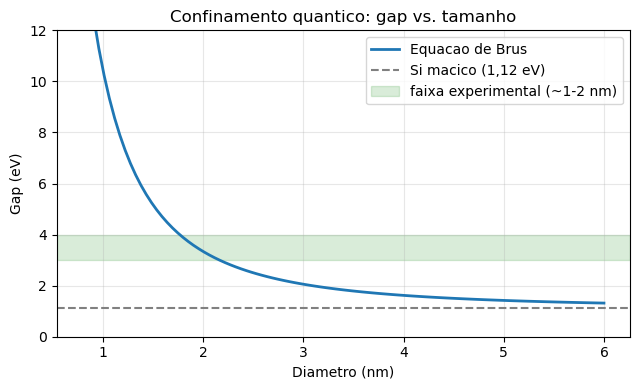

In [3]:
import matplotlib.pyplot as plt

diametros = np.linspace(0.8, 6.0, 100)
gaps = [gap_brus(d) for d in diametros]

plt.figure(figsize=(6.5, 4))
plt.plot(diametros, gaps, lw=2, label="Equacao de Brus")
plt.axhline(EG_BULK, ls="--", c="gray", label="Si macico (1,12 eV)")
plt.axhspan(3, 4, alpha=0.15, color="green", label="faixa experimental (~1-2 nm)")
plt.xlabel("Diametro (nm)"); plt.ylabel("Gap (eV)")
plt.title("Confinamento quantico: gap vs. tamanho")
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 12)
plt.tight_layout(); plt.show()

## 3.2 A rede do silício: a estrutura diamante

O Si cristaliza na **estrutura diamante**: uma rede cúbica de face centrada com base de dois átomos. A célula cúbica convencional tem **8 átomos**, parâmetro de rede $a = 5{,}431$ Å, e cada átomo tem exatamente **4 vizinhos** tetraédricos separados por

$$d_{\mathrm{Si-Si}} = \frac{\sqrt{3}}{4}\,a = 2{,}352~\text{Å}.$$

In [4]:
A_SI, D_SIH, CORTE = 5.431, 1.48, 2.6   # parametros em angstrom

def rede_diamante(n_celulas):
    """Gera as posicoes de Si de n x n x n celulas da rede diamante."""
    base = np.array([[0, 0, 0], [.25, .25, .25], [0, .5, .5], [.25, .75, .75],
                     [.5, 0, .5], [.75, .25, .75], [.5, .5, 0], [.75, .75, .25]])
    celulas = np.array([[i, j, k] for i in range(n_celulas)
                        for j in range(n_celulas) for k in range(n_celulas)])
    return (celulas[:, None, :] + base[None, :, :]).reshape(-1, 3) * A_SI

# Verificacao: uma celula deve ter 8 atomos e vizinhos a 2.352 A
uma = rede_diamante(1)
d = np.linalg.norm(uma[:, None] - uma[None, :], axis=2)
print("Atomos em 1 celula :", len(uma))
print("Menor distancia    : %.3f A  (esperado sqrt(3)/4 * a = %.3f A)"
      % (d[d > 0.1].min(), np.sqrt(3) / 4 * A_SI))
print("Atomos em 8x8x8    :", len(rede_diamante(8)))

Atomos em 1 celula : 8
Menor distancia    : 2.352 A  (esperado sqrt(3)/4 * a = 2.352 A)
Atomos em 8x8x8    : 4096


> 💡 **Broadcasting do NumPy.** A expressão `celulas[:, None, :] + base[None, :, :]` soma cada uma das $n^3$ translações de célula a cada uma das 8 posições da base, produzindo todas as combinações **de uma só vez**, sem laços aninhados. O `.reshape(-1, 3)` achata o resultado numa lista de coordenadas. Domine esse padrão — ele reaparece sempre que geometrias precisam ser construídas.

## 3.3 Do cristal ao nanocristal: corte e passivação

O nanocristal nasce em três etapas:

1. **Corte esférico** — mantemos apenas os átomos dentro de um raio $R$.
2. **Remoção de átomos instáveis** — todo Si com menos de 2 vizinhos é descartado, iterativamente (evita espécies quimicamente absurdas).
3. **Passivação** — cada *ligação pendente* recebe um hidrogênio a 1,48 Å, na direção do vizinho que faltou.

A passivação é essencial: ligações pendentes introduzem **estados dentro do *gap*** que contaminariam justamente a região que queremos estudar.

In [5]:
def construir_nanocristal(diametro_nm, n_celulas=8, min_viz=2):
    """Corta uma esfera da rede, remove atomos instaveis e passiva com H."""
    raio = diametro_nm * 10 / 2
    rede = rede_diamante(n_celulas)
    rede = rede - rede.mean(axis=0)                  # centraliza na origem
    dentro = np.linalg.norm(rede, axis=1) <= raio    # corte esferico

    while True:                                      # remove Si subcoordenados
        idx = np.where(dentro)[0]
        pos = rede[idx]
        nviz = [np.sum((np.linalg.norm(pos - p, axis=1) > 0.1) &
                       (np.linalg.norm(pos - p, axis=1) < CORTE)) for p in pos]
        ruins = idx[np.array(nviz) < min_viz]
        if len(ruins) == 0:
            break
        dentro[ruins] = False

    si = rede[dentro]
    hidrogenios = []                                 # passiva ligacoes pendentes
    for p in si:
        d = np.linalg.norm(rede - p, axis=1)
        for j in np.where((d > 0.1) & (d < CORTE))[0]:
            if not dentro[j]:                        # vizinho que ficou de fora
                u = (rede[j] - p) / d[j]             # direcao unitaria
                hidrogenios.append(p + D_SIH * u)
    return si, np.array(hidrogenios)

In [6]:
print("%-8s %-14s %8s %10s" % ("D (nm)", "formula", "atomos", "eletrons"))
for d in [1.0, 1.2, 1.5, 2.0]:
    si, h = construir_nanocristal(d)
    n_elec = 14 * len(si) + len(h)
    print("%-8.1f %-14s %8d %10d"
          % (d, "Si%dH%d" % (len(si), len(h)), len(si) + len(h), n_elec))

D (nm)   formula          atomos   eletrons
1.0      Si22H28              50        336
1.2      Si36H40              76        544
1.5      Si72H64             136       1072
2.0      Si202H138           340       2966


Note como o custo **explode**: dobrar o diâmetro multiplica o número de elétrons por quase nove. Essa é a realidade dura da química quântica — e a razão pela qual escolhemos **1,5 nm** como compromisso entre realismo físico e viabilidade computacional.

### Validando a estrutura

Nunca confie numa geometria gerada por código sem inspecioná-la. Três verificações baratas detectam a maioria dos erros.

In [7]:
si, h = construir_nanocristal(1.5)

# 1. Todo Si deve ter exatamente 4 ligacoes (Si vizinhos + H)
coord = []
for p in si:
    n_si = np.sum((np.linalg.norm(si - p, axis=1) > 0.1) &
                  (np.linalg.norm(si - p, axis=1) < CORTE))
    n_h = np.sum(np.linalg.norm(h - p, axis=1) < 1.6)
    coord.append(n_si + n_h)
print("Coordenacao: min=%d max=%d" % (min(coord), max(coord)))

# 2. Comprimentos de ligacao corretos?
d_sisi = np.linalg.norm(si[:, None] - si[None, :], axis=2)
print("Menor Si-Si: %.3f A" % d_sisi[d_sisi > 0.1].min())
print("Menor Si-H : %.3f A" % np.linalg.norm(si[:, None] - h[None, :], axis=2).min())

Coordenacao: min=4 max=4
Menor Si-Si: 2.352 A
Menor Si-H : 1.480 A


Todos os átomos de silício estão tetracoordenados — **nenhuma ligação pendente sobrou** — e os comprimentos de ligação são exatamente os esperados. A estrutura está quimicamente sã.

> ⚠️ **Uma geometria idealizada.** Nosso nanocristal foi recortado da rede *perfeita*, sem relaxamento. Átomos reais na superfície se reacomodam. Para resultados de publicação, o passo seguinte seria uma **otimização de geometria**. Mantemos a geometria ideal por clareza e custo, mas registre a limitação: ela afeta sobretudo os estados de superfície, e menos o estado do doador no centro — que é o nosso alvo.

## 3.4 Inserindo o doador: o sistema Si:P

Aqui está o coração do Projeto Âncora. O silício tem 4 elétrons de valência e usa todos nas ligações tetraédricas. O fósforo tem **5**: gasta quatro nas ligações e **sobra um**.

Esse elétron excedente fica fracamente ligado ao caroço P⁺, numa órbita difusa que lembra a de um átomo de hidrogênio — um "hidrogênio artificial" embutido no cristal. **Esse elétron solitário é o nosso *qubit*.**

In [8]:
def inserir_doador(si):
    """Devolve o indice do Si mais proximo do centro, a ser trocado por P."""
    return int(np.argmin(np.linalg.norm(si, axis=1)))

si, h = construir_nanocristal(1.5)
idx_p = inserir_doador(si)

n_elec = 14 * (len(si) - 1) + 15 + len(h)   # Si tem Z=14; P tem Z=15
print("Sistema: Si%d P1 H%d" % (len(si) - 1, len(h)))
print("Eletrons: %d  ->  spin (desemparelhados) = %d" % (n_elec, n_elec % 2))
print("Distancia do P ao centro: %.4f A" % np.linalg.norm(si[idx_p]))

Sistema: Si71 P1 H64
Eletrons: 1073  ->  spin (desemparelhados) = 1
Distancia do P ao centro: 1.1758 A


> 🔷 **O número ímpar que anuncia o *qubit*.** Repare no detalhe mais importante deste capítulo: o sistema tem **1073 elétrons — um número ímpar**. Num nanocristal de silício puro o total seria par, todos os elétrons emparelhados, e o sistema teria `spin=0`. O fósforo quebra essa paridade.
>
> Aquele elétron desemparelhado, que nos obrigará a usar `spin=1` e métodos de camada aberta (ROHF/UHF), **não é uma inconveniência técnica: é o *qubit***. Toda a física do resto do livro nasce dessa unidade solitária.

## 3.5 Mãos à Obra: exportar e visualizar

O formato `.xyz` é o esperanto das geometrias moleculares: primeira linha com o número de átomos, segunda um comentário livre, e as demais o símbolo e as coordenadas.

In [9]:
def para_xyz(si, h, idx_p=None, comentario="nanocristal"):
    linhas = ["%d" % (len(si) + len(h)), comentario]
    for i, p in enumerate(si):
        simbolo = "P" if i == idx_p else "Si"
        linhas.append("%-2s %10.6f %10.6f %10.6f" % (simbolo, *p))
    for p in h:
        linhas.append("%-2s %10.6f %10.6f %10.6f" % ("H", *p))
    return "\n".join(linhas)

si, h = construir_nanocristal(1.5)
idx_p = inserir_doador(si)
xyz = para_xyz(si, h, idx_p, "Si:P 1.5 nm - Projeto Ancora")

with open("SiP_1.5nm.xyz", "w") as f:
    f.write(xyz)

print("\n".join(xyz.split("\n")[:5]))
print("...")
print("arquivo salvo: SiP_1.5nm.xyz")

136
Si:P 1.5 nm - Projeto Ancora
Si  -6.109875  -3.394375  -0.678875
Si  -6.109875  -0.678875  -3.394375
Si  -6.109875  -0.678875   2.036625
...
arquivo salvo: SiP_1.5nm.xyz


Agora a visualização 3D interativa. Gire a estrutura com o mouse: você deve ver um aglomerado aproximadamente esférico, com o miolo de silício em arranjo tetraédrico regular e uma casca externa de hidrogênios. O átomo de fósforo (em cor distinta) está no centro — o mais longe possível da superfície.

In [10]:
try:
    import py3Dmol
    view = py3Dmol.view(width=600, height=460)
    view.addModel(xyz, "xyz")
    view.setStyle({"stick": {"radius": 0.12}, "sphere": {"scale": 0.22}})
    view.setStyle({"elem": "P"}, {"sphere": {"scale": 0.45, "color": "orange"}})
    view.zoomTo()
    view.show()
except ImportError:
    print("py3Dmol nao instalado - rode: pip install py3Dmol")
    print("Alternativa: abra SiP_1.5nm.xyz no Avogadro, VMD ou VESTA.")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

> 💡 **Sem py3Dmol?** O arquivo `SiP_1.5nm.xyz` pode ser aberto no **Avogadro**, **VMD** ou **VESTA** — todos gratuitos. O Avogadro é o mais amigável e permite medir ângulos e distâncias com o mouse.

## 3.6 Preparando para o PySCF

A mesma *string* XYZ (sem as duas primeiras linhas) alimenta diretamente o objeto `Mole`.

In [11]:
from pyscf import gto

geometria = "\n".join(xyz.split("\n")[2:])   # descarta cabecalho do xyz
mol = gto.M(atom=geometria, basis="sto-3g", spin=1)

print("Eletrons: %d | Funcoes de base: %d | spin: %d"
      % (mol.nelectron, mol.nao, mol.spin))

Eletrons: 1073 | Funcoes de base: 712 | spin: 1


O sistema está pronto para ser calculado — **712 funções de base é um cálculo sério**, que executaremos no Capítulo 4.

## 🔷 Projeto Âncora — Etapa 1 (parte A): a geometria do *qubit*

Você acaba de produzir o objeto físico central deste livro: um nanocristal **Si₇₁P₁H₆₄** de 1,5 nm, quimicamente saturado, com um doador de fósforo no centro e **um elétron desemparelhado** — o *qubit*.

A célula abaixo consolida o *pipeline* num único bloco reutilizável. **Guarde estas funções**: elas serão importadas em todos os capítulos seguintes.

In [12]:
# ---------------------------------------------------------------
# PIPELINE DO PROJETO ANCORA - Etapa 1A (geometria)
# Reutilizado nos Capitulos 4 em diante.
# ---------------------------------------------------------------
def resumo_sistema(diametro_nm=1.5, salvar=True):
    """Constroi o nanocristal Si:P, valida e devolve um resumo."""
    si, h = construir_nanocristal(diametro_nm)
    idx_p = inserir_doador(si)
    xyz = para_xyz(si, h, idx_p, "Si:P %.1f nm - Projeto Ancora" % diametro_nm)

    if salvar:
        nome = "SiP_%.1fnm.xyz" % diametro_nm
        with open(nome, "w") as f:
            f.write(xyz)

    n_elec = 14 * (len(si) - 1) + 15 + len(h)
    mol = gto.M(atom="\n".join(xyz.split("\n")[2:]),
                basis="sto-3g", spin=n_elec % 2, verbose=0)
    return {
        "diametro_nm": diametro_nm,
        "formula": "Si%dP1H%d" % (len(si) - 1, len(h)),
        "n_atomos": len(si) + len(h),
        "n_eletrons": n_elec,
        "spin": n_elec % 2,
        "n_base": mol.nao,
        "xyz": xyz,
    }

info = resumo_sistema(1.5)
for k in ["diametro_nm", "formula", "n_atomos", "n_eletrons", "spin", "n_base"]:
    print("%-12s : %s" % (k, info[k]))

diametro_nm  : 1.5
formula      : Si71P1H64
n_atomos     : 136
n_eletrons   : 1073
spin         : 1
n_base       : 712


**Marco atingido.** A geometria do *qubit* está pronta e exportada.

**A seguir.** No Capítulo 4 submeteremos essa geometria a um cálculo Hartree-Fock, localizaremos o **orbital do doador** entre os 712 orbitais moleculares e mediremos o *gap* de confinamento — comparando-o com os 5,16 eV que a equação de Brus previu. A comparação será reveladora.

## Exercícios

Resolva nas células abaixo.

**3.1 Escala do confinamento.** Usando $E_1 = \hbar^2\pi^2/2mR^2$ com $m = m_0$, calcule $E_1$ para $R = 5$, $10$ e $20$ Å. Verifique numericamente que dobrar o raio divide a energia por 4.

**3.2 Limite do modelo de Brus.** Avalie `gap_brus` de 0,8 a 6,0 nm e faça o gráfico. A partir de qual diâmetro a previsão passa a parecer fisicamente razoável (abaixo de ~4 eV)?

**3.3 Contagem atômica.** A densidade do Si é ≈ 0,0500 átomos/Å³. Estime analiticamente quantos átomos caberiam numa esfera de 1,5 nm e compare com os 72 obtidos pelo código. Explique a diferença.

**3.4 Efeito da passivação.** Modifique `construir_nanocristal` para *não* passivar e conte quantas ligações pendentes existiriam no nanocristal de 1,5 nm.

**3.5 Critério de estabilidade.** Refaça a construção com `min_viz=1` e `min_viz=3`. Como mudam a fórmula e a razão H/Si? Qual critério lhe parece quimicamente mais defensável?

**3.6 Posição do doador.** Modifique `inserir_doador` para colocar o fósforo num átomo da *superfície*. Por que essa escolha seria ruim para um *qubit*?

**3.7 Projeto Âncora.** Gere nanocristais de Si:P de 1,0 e 2,0 nm além do de 1,5 nm. Monte uma tabela com fórmula, número de elétrons e funções de base.

In [13]:
# 3.1 Escala do confinamento

In [14]:
# 3.3 Contagem atomica

In [15]:
# 3.5 Criterio de estabilidade (min_viz)

In [16]:
# 3.7 Projeto Ancora: tabela de nanocristais